In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import cv2
import os
from emotiefflib.facial_analysis import EmotiEffLibRecognizer, get_model_list, EmotiEffLibRecognizerTorch

In [16]:
# Parameters
base_data_folder = "../data/CityInfant/"
num_folds = 5
image_size = 224  # Double check this?? 
batch_size = 32
num_epochs = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}

model_name = get_model_list()[1]
print(f"Using model: {model_name}")

num_classes = 3


Using model: enet_b0_8_best_afew


In [3]:
data_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# Custom Dataset Class
class AffectDataset(Dataset):
    def __init__(self, image_names, labels, images_folder, transform=None):
        self.image_names = image_names
        self.labels = labels
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        image_path = os.path.join(self.images_folder, img_name)

        try:
            image = cv2.imread(image_path)
            if image is None:
                raise ValueError(f"Could not read image at: {image_path}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(image)
        except Exception as e:
            print(f"Error loading image: {image_path} - {e}")
            raise  

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


In [7]:
# Initialize model
recognizer = EmotiEffLibRecognizer(model_name=model_name, engine="torch", device=device)

In [10]:
fold_accuracies = []

# Loop through each train-test split
for fold in range(1, num_folds + 1):
    print(f"\n=== Processing Fold {fold} ===")

    train_folder = os.path.join(base_data_folder, 'train-test', f"train{fold}")
    test_folder = os.path.join(base_data_folder, 'train-test', f"test{fold}")
    label_file = os.path.join(base_data_folder, "Validationinfo", "labels.csv")

    # Load labels
    df = pd.read_csv(label_file)
    df = df[df["Image"].isin(os.listdir(train_folder) + os.listdir(test_folder))]
    
    train_df = df[df["Image"].isin(os.listdir(train_folder))]
    test_df = df[df["Image"].isin(os.listdir(test_folder))]

    X_train, y_train = train_df["Image"].tolist(), train_df["imageCat"].tolist()
    X_test, y_test = test_df["Image"].tolist(), test_df["imageCat"].tolist()

    # Create datasets and dataloaders
    train_dataset = AffectDataset(X_train, y_train, train_folder, transform=data_transforms)
    test_dataset = AffectDataset(X_test, y_test, test_folder, transform=data_transforms)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

    # Load fresh model for each fold
    model = recognizer.model
    in_features = recognizer.classifier_weights.shape[1]
    model.classifier = nn.Linear(in_features, num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

    # Train the model
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_dataloader)
        epoch_acc = correct_predictions / total_samples
        print(f"Fold {fold} - Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
    
    model_path = f"../models/{model_name}_fold{fold}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved: {model_path}")

#     # Evaluate on test set
#     model.eval()
#     correct_predictions = 0
#     total_samples = 0

#     with torch.no_grad():
#         for images, labels in test_dataloader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             _, predicted = torch.max(outputs, 1)
#             total_samples += labels.size(0)
#             correct_predictions += (predicted == labels).sum().item()

#     fold_accuracy = correct_predictions / total_samples
#     fold_accuracies.append(fold_accuracy)
#     print(f"Fold {fold} Test Accuracy: {fold_accuracy:.4f}")

# # Compute average test accuracy across all folds
# average_accuracy = np.mean(fold_accuracies)
# print("\nFinal Cross-Validation Accuracy:", average_accuracy)


=== Processing Fold 1 ===
Fold 1 - Epoch 1/8, Loss: 0.9550, Accuracy: 0.5208
Fold 1 - Epoch 2/8, Loss: 0.8199, Accuracy: 0.6875
Fold 1 - Epoch 3/8, Loss: 0.7181, Accuracy: 0.7292
Fold 1 - Epoch 4/8, Loss: 0.6503, Accuracy: 0.8229
Fold 1 - Epoch 5/8, Loss: 0.6214, Accuracy: 0.8438
Fold 1 - Epoch 6/8, Loss: 0.5960, Accuracy: 0.8750
Fold 1 - Epoch 7/8, Loss: 0.5830, Accuracy: 0.8854
Fold 1 - Epoch 8/8, Loss: 0.4545, Accuracy: 0.9167
Model saved: ../models/enet_b0_8_best_afew_fold1.pth

=== Processing Fold 2 ===
Fold 2 - Epoch 1/8, Loss: 1.0800, Accuracy: 0.3958
Fold 2 - Epoch 2/8, Loss: 0.8691, Accuracy: 0.6250
Fold 2 - Epoch 3/8, Loss: 0.8085, Accuracy: 0.7083
Fold 2 - Epoch 4/8, Loss: 0.6919, Accuracy: 0.8854
Fold 2 - Epoch 5/8, Loss: 0.6217, Accuracy: 0.8750
Fold 2 - Epoch 6/8, Loss: 0.6085, Accuracy: 0.8958
Fold 2 - Epoch 7/8, Loss: 0.5946, Accuracy: 0.8750
Fold 2 - Epoch 8/8, Loss: 0.4831, Accuracy: 0.9062
Model saved: ../models/enet_b0_8_best_afew_fold2.pth

=== Processing Fold 3 =

~ 9 min


Evaluating Fold 1...


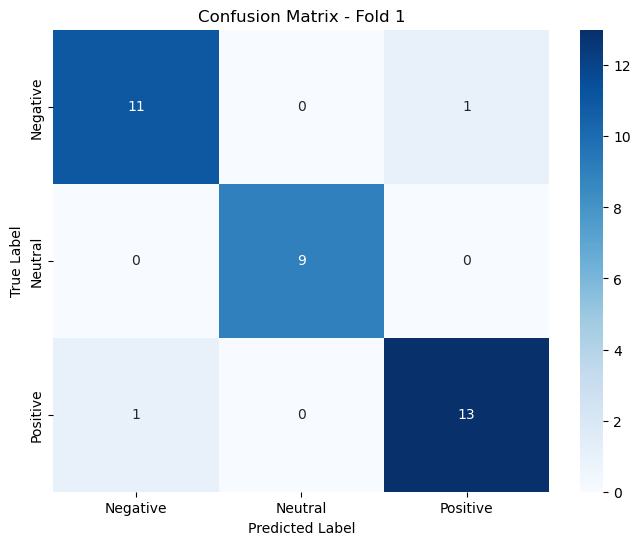


Classification Report for Fold 1:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92        12
     Neutral       1.00      1.00      1.00         9
    Positive       0.93      0.93      0.93        14

    accuracy                           0.94        35
   macro avg       0.95      0.95      0.95        35
weighted avg       0.94      0.94      0.94        35


Evaluating Fold 2...


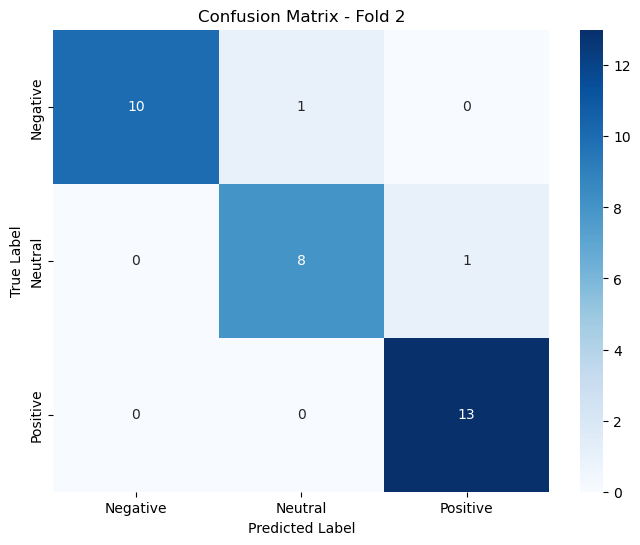


Classification Report for Fold 2:
              precision    recall  f1-score   support

    Negative       1.00      0.91      0.95        11
     Neutral       0.89      0.89      0.89         9
    Positive       0.93      1.00      0.96        13

    accuracy                           0.94        33
   macro avg       0.94      0.93      0.93        33
weighted avg       0.94      0.94      0.94        33


Evaluating Fold 3...


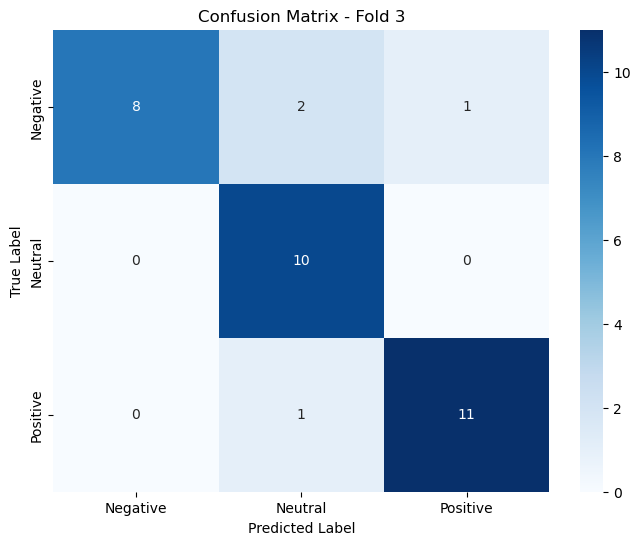


Classification Report for Fold 3:
              precision    recall  f1-score   support

    Negative       1.00      0.73      0.84        11
     Neutral       0.77      1.00      0.87        10
    Positive       0.92      0.92      0.92        12

    accuracy                           0.88        33
   macro avg       0.90      0.88      0.88        33
weighted avg       0.90      0.88      0.88        33


Evaluating Fold 4...


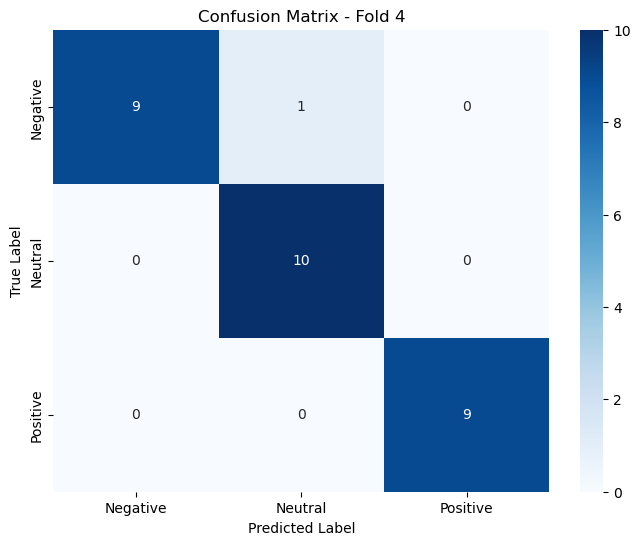


Classification Report for Fold 4:
              precision    recall  f1-score   support

    Negative       1.00      0.90      0.95        10
     Neutral       0.91      1.00      0.95        10
    Positive       1.00      1.00      1.00         9

    accuracy                           0.97        29
   macro avg       0.97      0.97      0.97        29
weighted avg       0.97      0.97      0.97        29


Evaluating Fold 5...


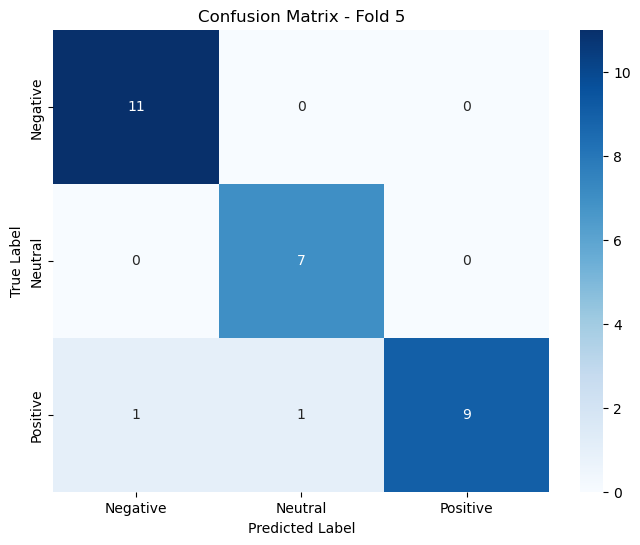


Classification Report for Fold 5:
              precision    recall  f1-score   support

    Negative       0.92      1.00      0.96        11
     Neutral       0.88      1.00      0.93         7
    Positive       1.00      0.82      0.90        11

    accuracy                           0.93        29
   macro avg       0.93      0.94      0.93        29
weighted avg       0.94      0.93      0.93        29


Misclassified Images:
Fold 1: [('B5PosBW.bmp', 'Negative'), ('B13NegBW.bmp', 'Positive')]
Fold 2: [('G13NegBW.bmp', 'Neutral'), ('G23NeuBW.bmp', 'Positive')]
Fold 3: [('B21PosBW.bmp', 'Neutral'), ('G15NegBW.bmp', 'Neutral'), ('G24NegBW.bmp', 'Neutral'), ('G29NegBW.bmp', 'Positive')]
Fold 4: [('G15NegBW.bmp', 'Neutral')]
Fold 5: [('B5PosBW.bmp', 'Negative'), ('G31PosBW.bmp', 'Neutral')]


In [20]:
misclassified_images_dict = {}

# Evaluate each fold separately
for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}...")

    test_folder = os.path.join(base_data_folder, 'train-test', f"test{fold}")
    label_file = os.path.join(base_data_folder, "Validationinfo", "labels.csv")

    # Load test labels
    df = pd.read_csv(label_file)
    test_df = df[df["Image"].isin(os.listdir(test_folder))]
    X_test, y_test = test_df["Image"].tolist(), test_df["imageCat"].tolist()

    # Create dataset and dataloader
    test_dataset = AffectDataset(X_test, y_test, test_folder, transform=data_transforms)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

    # Load the corresponding model
    model_path = f"../models/{model_name}_fold{fold}.pth"
    model = recognizer.model
    in_features = recognizer.classifier_weights.shape[1]
    model.classifier = nn.Linear(in_features, num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Store predictions and misclassified images
    all_preds = []
    all_labels = []
    misclassified_images = []

    with torch.no_grad():
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Save misclassified images
            for img, true_label, pred_label, img_name in zip(images, labels, predicted, X_test):
                if true_label != pred_label:
                    misclassified_images.append((img_name, class_labels[pred_label.item()]))
                    

    # Store misclassified image names for this fold
    misclassified_images_dict[f"Fold {fold}"] = misclassified_images

    # **Plot Confusion Matrix**
    cm = confusion_matrix(all_labels, all_preds)
    class_names = ["Negative", "Neutral", "Positive"]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

    # Print classification report
    print(f"\nClassification Report for Fold {fold}:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Print all misclassified images
print("\nMisclassified Images:")
for fold, images in misclassified_images_dict.items():
    print(f"{fold}: {images[:10]}") 


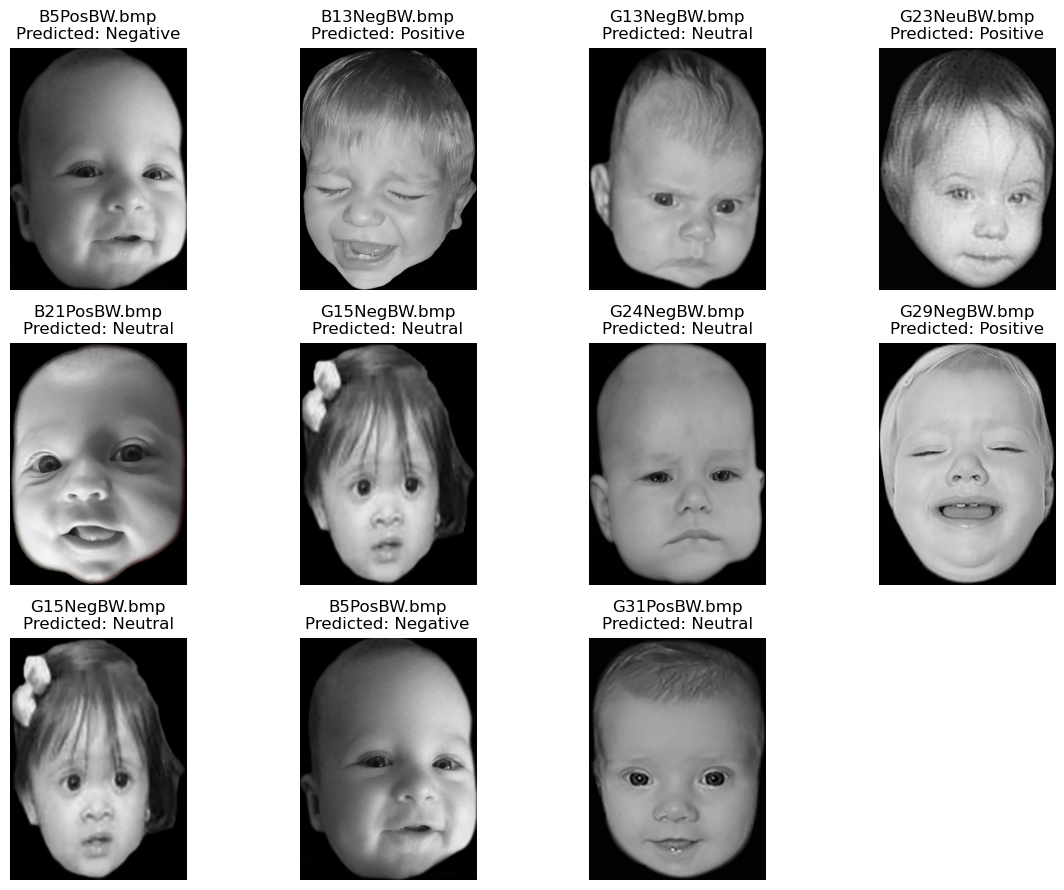

In [22]:
# Combine all misclassified images into one list
all_misclassified_images = []

# Loop through each fold and add misclassified images to the list
for fold, images in misclassified_images_dict.items():
    all_misclassified_images.extend(images)

# Create a grid of images (adjust grid size depending on the number of misclassified images)
num_images = len(all_misclassified_images)
cols = min(num_images, 4)  # Show up to 4 images per row (you can adjust this)
rows = (num_images + cols - 1) // cols  # Calculate rows required

# Create the plot grid
plt.figure(figsize=(cols * 3, rows * 3))
for i, (img_name, predicted_label) in enumerate(all_misclassified_images):
    img_path = os.path.join(base_data_folder,'BlackWhite', img_name)  # Get the image path
    
    # Load image with OpenCV
    frame_bgr = cv2.imread(img_path)
    if frame_bgr is None:
        print(f"Image {img_name} not found.")
        continue

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    image = Image.fromarray(frame_rgb)  # Convert to PIL Image

    # Plot image
    plt.subplot(rows, cols, i + 1)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title(f"{img_name}\nPredicted: {predicted_label}")

plt.tight_layout()
plt.show()